<a href="https://colab.research.google.com/github/Ekamk007/air-quality-dashboard/blob/main/Stock_Sentiment_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market News Sentiment Analysis
### RNN · LSTM · GRU · Random Forest — Full Pipeline
Run every cell top to bottom. At the end you will have all model files ready to download and drop into your Streamlit app.

---
## CELL 1 — Install libraries

In [1]:
!pip install -q sentence-transformers gensim torch torchvision xgboost
print('All libraries installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.1 MB/s eta 0:00:00
All libraries installed


---
## CELL 2 — Mount Google Drive & upload your CSV

In [2]:
from google.colab import drive, files
drive.mount('/content/drive')

import os
os.makedirs('/content/data', exist_ok=True)
os.makedirs('/content/models', exist_ok=True)

# Upload stock_news.csv when prompted
uploaded = files.upload()
for fname in uploaded:
    with open(f'/content/data/{fname}', 'wb') as f:
        f.write(uploaded[fname])
print('File uploaded to /content/data/')

Mounted at /content/drive


Saving stock_news (1).csv to stock_news (1).csv
File uploaded to /content/data/


---
## CELL 3 — Import all libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, joblib, pickle, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print('All imports successful')

Using device: cpu
All imports successful


---
## CELL 4 — Load dataset

In [6]:
df_org = pd.read_csv('stock_news (1).csv')
df = df_org.copy()
df['Date'] = pd.to_datetime(df['Date'])

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Null values:\n', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
df.head()

Shape: (349, 8)
Columns: ['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label']
Null values:
 Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64
Duplicates: 0


,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


---
## CELL 5 — EDA: Sentiment distribution

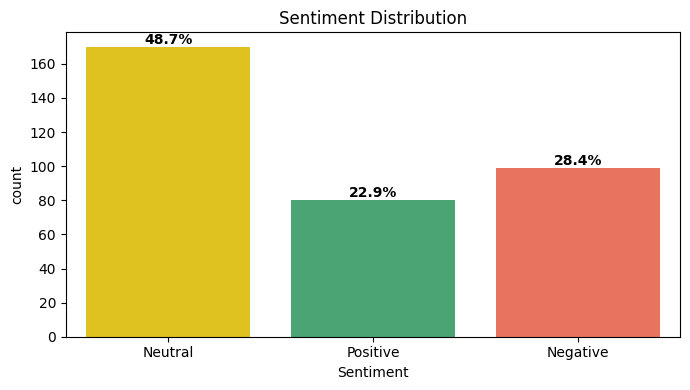

Sentiment
Neutral     170
Negative     99
Positive     80
Name: count, dtype: int64


In [7]:
sentiment_map = {0: 'Neutral', 1: 'Positive', -1: 'Negative'}
df['Sentiment'] = df['Label'].map(sentiment_map)
palette = {'Neutral': 'gold', 'Positive': 'mediumseagreen', 'Negative': 'tomato'}

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Sentiment', order=['Neutral','Positive','Negative'], palette=palette)
total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.show()

print(df['Sentiment'].value_counts())

---
## CELL 6 — EDA: News length, price trends, correlation

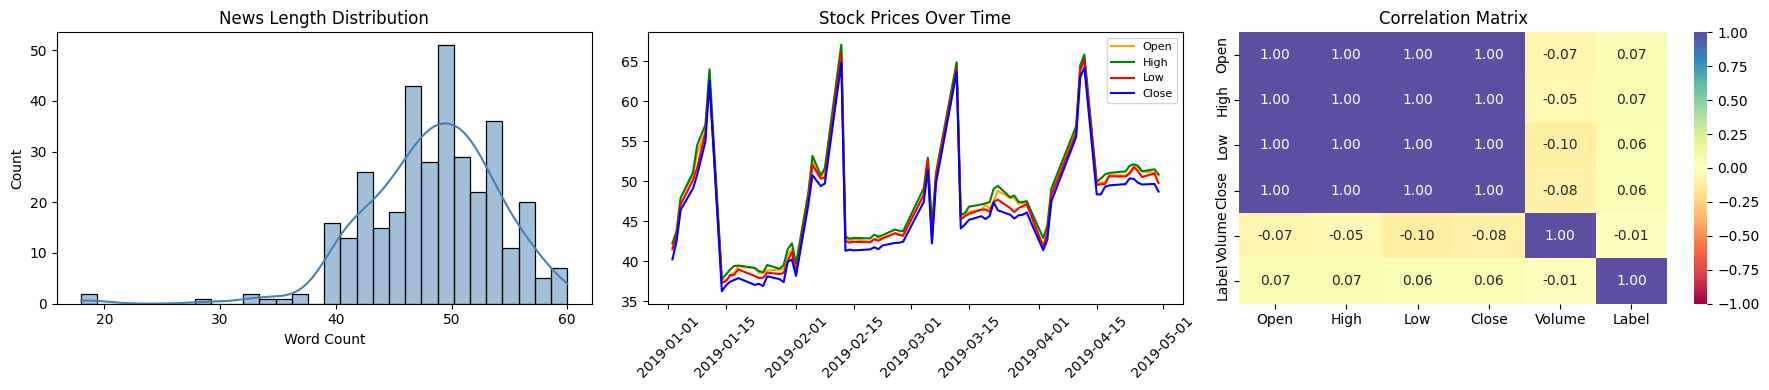

In [8]:
df['news_len'] = df['News'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# News length histogram
sns.histplot(df['news_len'], kde=True, bins=30, color='steelblue', ax=axes[0])
axes[0].set_title('News Length Distribution')
axes[0].set_xlabel('Word Count')

# Price line chart
stock_daily = df.groupby('Date')[['Open','High','Low','Close']].mean()
for col, color in zip(['Open','High','Low','Close'], ['orange','green','red','blue']):
    axes[1].plot(stock_daily.index, stock_daily[col], label=col, color=color)
axes[1].set_title('Stock Prices Over Time')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

# Correlation heatmap
num_cols = df[['Open','High','Low','Close','Volume','Label']]
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='Spectral',
            vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

---
## CELL 7 — Text cleaning

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

df['Clean_News'] = df['News'].apply(clean_text)

print('Sample before:', df['News'].iloc[0])
print('Sample after: ', df['Clean_News'].iloc[0])

Sample before:  The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.
Sample after:  tech sector experienced significant decline aftermarket following apples revenue warning notable suppliers including skyworks broadcom lumentum qorvo tsmc saw stocks drop response apples downward revision revenue expectations quarter previously announced january


---
## CELL 8 — Train / Val / Test split (same dates as reference notebook)

In [10]:
X_train = df[df['Date'] < '2019-04-01'].reset_index(drop=True)
X_val   = df[(df['Date'] >= '2019-04-01') & (df['Date'] < '2019-04-16')].reset_index(drop=True)
X_test  = df[df['Date'] >= '2019-04-16'].reset_index(drop=True)

y_train = X_train['Label'].copy()
y_val   = X_val['Label'].copy()
y_test  = X_test['Label'].copy()

# Save splits for the Streamlit app
X_train.to_csv('/content/data/train.csv', index=False)
X_val.to_csv('/content/data/val.csv', index=False)
X_test.to_csv('/content/data/test.csv', index=False)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (286, 11) | Val: (21, 11) | Test: (42, 11)


---
## CELL 9 — Build vocabulary (needed by RNN / LSTM / GRU)

In [11]:
from collections import Counter

all_tokens = [token for text in df['Clean_News'] for token in text.split()]
freq = Counter(all_tokens)

# Keep words that appear at least 2 times
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in freq.items():
    if count >= 2:
        vocab[word] = len(vocab)

with open('/content/models/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

print(f'Vocabulary size: {len(vocab)}')

Vocabulary size: 1531


---
## CELL 10 — Word2Vec embeddings

In [12]:
VEC_SIZE = 100

words_list = [text.split() for text in df['Clean_News']]
w2v_model = Word2Vec(words_list, vector_size=VEC_SIZE, min_count=1, window=5, workers=4, epochs=10)
w2v_model.save('/content/models/w2v.model')

def sentence_to_vec(text, model, size=VEC_SIZE):
    words = text.split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

print(f'Word2Vec trained. Vocab size: {len(w2v_model.wv)}')

Word2Vec trained. Vocab size: 3350


---
## CELL 11 — Sentence Transformer embeddings (for classical ML)

In [13]:
print('Loading Sentence Transformer... (takes ~1 min on first run)')
st_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_st = st_model.encode(X_train['Clean_News'].tolist(), show_progress_bar=True)
X_val_st   = st_model.encode(X_val['Clean_News'].tolist(),   show_progress_bar=True)
X_test_st  = st_model.encode(X_test['Clean_News'].tolist(),  show_progress_bar=True)

np.save('/content/models/st_train.npy', X_train_st)
np.save('/content/models/st_val.npy',   X_val_st)
np.save('/content/models/st_test.npy',  X_test_st)

print(f'Embeddings shape — Train: {X_train_st.shape}, Val: {X_val_st.shape}, Test: {X_test_st.shape}')

Loading Sentence Transformer... (takes ~1 min on first run)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings shape — Train: (286, 384), Val: (21, 384), Test: (42, 384)


---
## CELL 12 — Helper: model performance metrics

In [14]:
def get_metrics(model, X, y):
    preds = model.predict(X)
    return {
        'Accuracy':  round(float(accuracy_score(y, preds)), 4),
        'Precision': round(float(precision_score(y, preds, average='weighted', zero_division=0)), 4),
        'Recall':    round(float(recall_score(y, preds, average='weighted', zero_division=0)), 4),
        'F1':        round(float(f1_score(y, preds, average='weighted', zero_division=0)), 4)
    }

def plot_cm(model, X, y, title):
    preds = model.predict(X)
    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[-1,0,1], yticklabels=[-1,0,1])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

print('Helper functions defined')

Helper functions defined


---
## CELL 13 — Train Random Forest (classical ML baseline)

Training Random Forest...
Train: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
Val:   {'Accuracy': 0.5714, 'Precision': 0.3265, 'Recall': 0.5714, 'F1': 0.4156}
Test:  {'Accuracy': 0.5476, 'Precision': 0.768, 'Recall': 0.5476, 'F1': 0.4482}


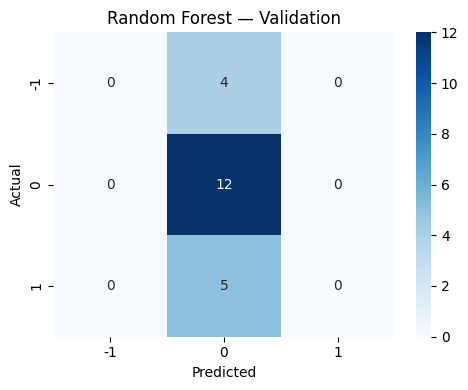

Random Forest saved.


In [15]:
print('Training Random Forest...')

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_st, y_train)

rf_train_metrics = get_metrics(rf, X_train_st, y_train)
rf_val_metrics   = get_metrics(rf, X_val_st,   y_val)
rf_test_metrics  = get_metrics(rf, X_test_st,  y_test)

print('Train:', rf_train_metrics)
print('Val:  ', rf_val_metrics)
print('Test: ', rf_test_metrics)

plot_cm(rf, X_val_st, y_val, 'Random Forest — Validation')

joblib.dump(rf, '/content/models/rf_model.pkl')
with open('/content/models/rf_metrics.json', 'w') as f:
    json.dump({'train': rf_train_metrics, 'val': rf_val_metrics, 'test': rf_test_metrics}, f)

print('Random Forest saved.')

---
## CELL 14 — PyTorch Dataset & tokenizer (shared by RNN / LSTM / GRU)

In [16]:
LABEL_MAP = {-1: 0, 0: 1, 1: 2}   # convert -1/0/1 → 0/1/2 for CrossEntropyLoss
MAX_LEN   = 60

def tokenize(text, vocab, max_len=MAX_LEN):
    tokens = text.split()
    ids = [vocab.get(t, 1) for t in tokens]  # 1 = <UNK>
    ids = ids[:max_len]
    ids += [0] * (max_len - len(ids))        # 0 = <PAD>
    return ids

class NewsDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.X = [torch.tensor(tokenize(t, vocab), dtype=torch.long) for t in texts]
        self.y = torch.tensor([LABEL_MAP[l] for l in labels], dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_ds = NewsDataset(X_train['Clean_News'], y_train, vocab)
val_ds   = NewsDataset(X_val['Clean_News'],   y_val,   vocab)
test_ds  = NewsDataset(X_test['Clean_News'],  y_test,  vocab)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)
test_dl  = DataLoader(test_ds,  batch_size=32)

print(f'Train batches: {len(train_dl)} | Val batches: {len(val_dl)} | Test batches: {len(test_dl)}')

Train batches: 9 | Val batches: 1 | Test batches: 2


---
## CELL 15 — Training loop helper (shared by all 3 deep learning models)

In [17]:
def train_model(model, train_dl, val_dl, epochs=25, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for X_batch, y_batch in train_dl:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_correct += (out.argmax(1) == y_batch).sum().item()
            t_total += y_batch.size(0)

        # --- Validate ---
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_dl:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                out = model(X_batch)
                loss = criterion(out, y_batch)
                v_loss += loss.item()
                v_correct += (out.argmax(1) == y_batch).sum().item()
                v_total += y_batch.size(0)

        t_l = round(t_loss/len(train_dl), 4)
        v_l = round(v_loss/len(val_dl),   4)
        t_a = round(t_correct/t_total,    4)
        v_a = round(v_correct/v_total,    4)
        history['train_loss'].append(t_l)
        history['val_loss'].append(v_l)
        history['train_acc'].append(t_a)
        history['val_acc'].append(v_a)
        if (epoch+1) % 5 == 0:
            print(f'Epoch {epoch+1:02d}/{epochs} | Train Loss: {t_l:.4f} Acc: {t_a:.4f} | Val Loss: {v_l:.4f} Acc: {v_a:.4f}')

    return history


def eval_deep(model, dl):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in dl:
            X_batch = X_batch.to(DEVICE)
            out = model(X_batch)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    acc  = round(accuracy_score(all_labels, all_preds), 4)
    f1   = round(f1_score(all_labels, all_preds, average='weighted', zero_division=0), 4)
    prec = round(precision_score(all_labels, all_preds, average='weighted', zero_division=0), 4)
    rec  = round(recall_score(all_labels, all_preds, average='weighted', zero_division=0), 4)
    return {'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec}


def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val')
    ax2.set_title(f'{title} — Accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.show()

print('Training helpers defined')

Training helpers defined


---
## CELL 16 — Vanilla RNN model

Training Vanilla RNN...
Epoch 05/25 | Train Loss: 1.0521 Acc: 0.4825 | Val Loss: 0.9998 Acc: 0.5714
Epoch 10/25 | Train Loss: 1.0515 Acc: 0.4825 | Val Loss: 1.0052 Acc: 0.5714
Epoch 15/25 | Train Loss: 1.0536 Acc: 0.4825 | Val Loss: 0.9998 Acc: 0.5714
Epoch 20/25 | Train Loss: 1.0497 Acc: 0.4825 | Val Loss: 1.0077 Acc: 0.5714
Epoch 25/25 | Train Loss: 1.0513 Acc: 0.4825 | Val Loss: 1.0105 Acc: 0.5714
Val:  {'Accuracy': 0.5714, 'F1': 0.4156, 'Precision': 0.3265, 'Recall': 0.5714}
Test: {'Accuracy': 0.4762, 'F1': 0.3072, 'Precision': 0.2268, 'Recall': 0.4762}


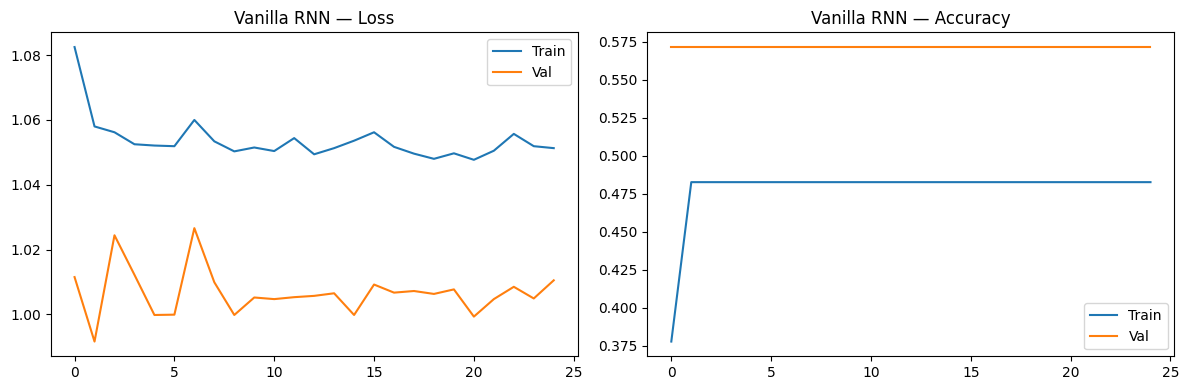

RNN saved.


In [18]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq, embed)
        _, h = self.rnn(x)             # h: (1, batch, hidden)
        h = self.dropout(h.squeeze(0)) # (batch, hidden)
        return self.fc(h)


print('Training Vanilla RNN...')
rnn_model = RNNModel(vocab_size=len(vocab))
rnn_history = train_model(rnn_model, train_dl, val_dl, epochs=25)

rnn_val_metrics  = eval_deep(rnn_model, val_dl)
rnn_test_metrics = eval_deep(rnn_model, test_dl)
print('Val: ', rnn_val_metrics)
print('Test:', rnn_test_metrics)

plot_history(rnn_history, 'Vanilla RNN')

torch.save(rnn_model.state_dict(), '/content/models/rnn_model.pt')
with open('/content/models/rnn_history.json', 'w') as f:
    json.dump(rnn_history, f)
with open('/content/models/rnn_metrics.json', 'w') as f:
    json.dump({'val': rnn_val_metrics, 'test': rnn_test_metrics}, f)

print('RNN saved.')

---
## CELL 17 — LSTM model

Training LSTM...
Epoch 05/25 | Train Loss: 1.0522 Acc: 0.4825 | Val Loss: 1.0117 Acc: 0.5714
Epoch 10/25 | Train Loss: 1.0512 Acc: 0.4825 | Val Loss: 1.0100 Acc: 0.5714
Epoch 15/25 | Train Loss: 1.0533 Acc: 0.4825 | Val Loss: 1.0053 Acc: 0.5714
Epoch 20/25 | Train Loss: 1.0479 Acc: 0.4825 | Val Loss: 1.0047 Acc: 0.5714
Epoch 25/25 | Train Loss: 1.0484 Acc: 0.4825 | Val Loss: 1.0083 Acc: 0.5714
Val:  {'Accuracy': 0.5714, 'F1': 0.4156, 'Precision': 0.3265, 'Recall': 0.5714}
Test: {'Accuracy': 0.4762, 'F1': 0.3072, 'Precision': 0.2268, 'Recall': 0.4762}


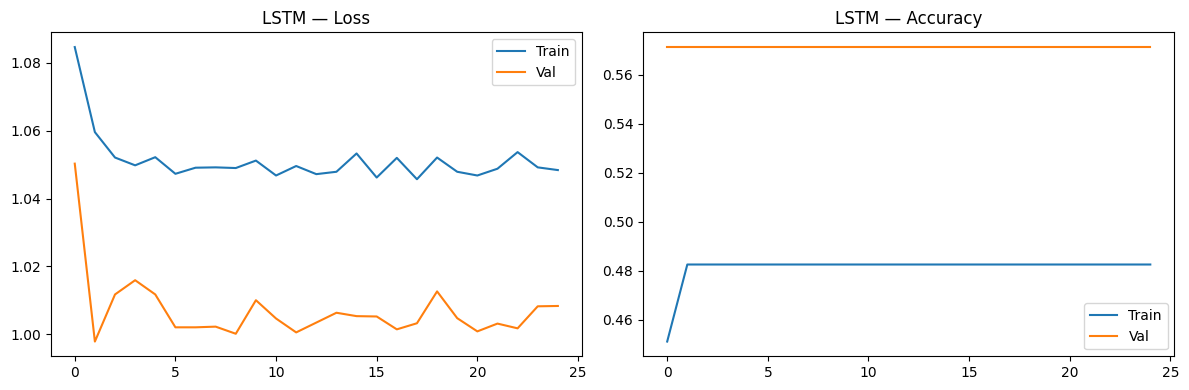

LSTM saved.


In [19]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)              # (batch, seq, embed)
        _, (h, c) = self.lstm(x)           # h: (1, batch, hidden)
        h = self.dropout(h.squeeze(0))     # (batch, hidden)
        return self.fc(h)


print('Training LSTM...')
lstm_model = LSTMModel(vocab_size=len(vocab))
lstm_history = train_model(lstm_model, train_dl, val_dl, epochs=25)

lstm_val_metrics  = eval_deep(lstm_model, val_dl)
lstm_test_metrics = eval_deep(lstm_model, test_dl)
print('Val: ', lstm_val_metrics)
print('Test:', lstm_test_metrics)

plot_history(lstm_history, 'LSTM')

torch.save(lstm_model.state_dict(), '/content/models/lstm_model.pt')
with open('/content/models/lstm_history.json', 'w') as f:
    json.dump(lstm_history, f)
with open('/content/models/lstm_metrics.json', 'w') as f:
    json.dump({'val': lstm_val_metrics, 'test': lstm_test_metrics}, f)

print('LSTM saved.')

---
## CELL 18 — GRU model

Training GRU...
Epoch 05/25 | Train Loss: 1.0517 Acc: 0.4825 | Val Loss: 1.0036 Acc: 0.5714
Epoch 10/25 | Train Loss: 1.0427 Acc: 0.4825 | Val Loss: 0.9984 Acc: 0.5714
Epoch 15/25 | Train Loss: 0.7638 Acc: 0.6049 | Val Loss: 1.0189 Acc: 0.4762
Epoch 20/25 | Train Loss: 0.7021 Acc: 0.6434 | Val Loss: 0.9664 Acc: 0.4762
Epoch 25/25 | Train Loss: 0.6459 Acc: 0.6608 | Val Loss: 0.8926 Acc: 0.4762
Val:  {'Accuracy': 0.4762, 'F1': 0.4612, 'Precision': 0.6222, 'Recall': 0.4762}
Test: {'Accuracy': 0.4048, 'F1': 0.3557, 'Precision': 0.4029, 'Recall': 0.4048}


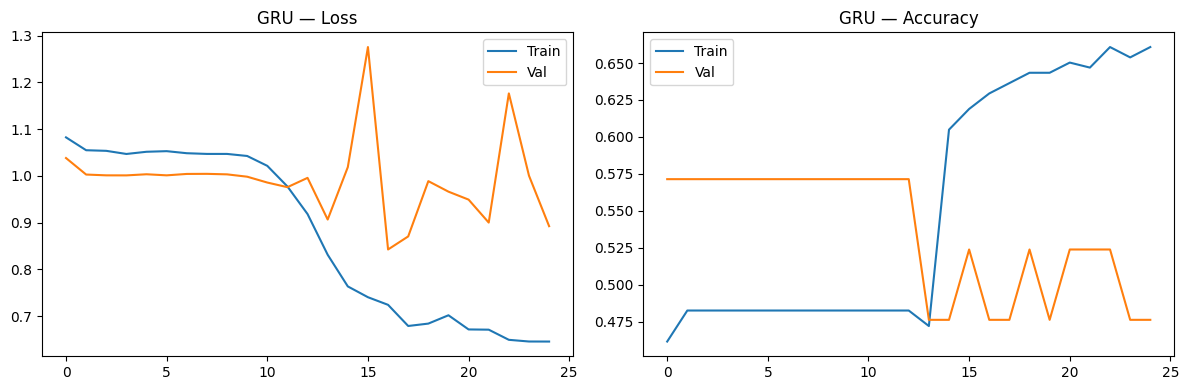

GRU saved.


In [20]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq, embed)
        _, h = self.gru(x)             # h: (1, batch, hidden)
        h = self.dropout(h.squeeze(0)) # (batch, hidden)
        return self.fc(h)


print('Training GRU...')
gru_model = GRUModel(vocab_size=len(vocab))
gru_history = train_model(gru_model, train_dl, val_dl, epochs=25)

gru_val_metrics  = eval_deep(gru_model, val_dl)
gru_test_metrics = eval_deep(gru_model, test_dl)
print('Val: ', gru_val_metrics)
print('Test:', gru_test_metrics)

plot_history(gru_history, 'GRU')

torch.save(gru_model.state_dict(), '/content/models/gru_model.pt')
with open('/content/models/gru_history.json', 'w') as f:
    json.dump(gru_history, f)
with open('/content/models/gru_metrics.json', 'w') as f:
    json.dump({'val': gru_val_metrics, 'test': gru_test_metrics}, f)

print('GRU saved.')

---
## CELL 19 — Model comparison summary table

In [21]:
rows = []
for name, val_m, test_m in [
    ('Random Forest', rf_val_metrics,   rf_test_metrics),
    ('Vanilla RNN',   rnn_val_metrics,  rnn_test_metrics),
    ('LSTM',          lstm_val_metrics, lstm_test_metrics),
    ('GRU',           gru_val_metrics,  gru_test_metrics),
]:
    rows.append({'Model': name,
                 'Val Acc':  val_m['Accuracy'],  'Val F1':  val_m['F1'],
                 'Test Acc': test_m['Accuracy'], 'Test F1': test_m['F1']})

comp_df = pd.DataFrame(rows).set_index('Model')
print('\n=== Model Comparison ===')
print(comp_df.to_string())

comp_df.to_csv('/content/models/model_comparison.csv')
print('\nSaved to /content/models/model_comparison.csv')


=== Model Comparison ===
               Val Acc  Val F1  Test Acc  Test F1
Model                                            
Random Forest   0.5714  0.4156    0.5476   0.4482
Vanilla RNN     0.5714  0.4156    0.4762   0.3072
LSTM            0.5714  0.4156    0.4762   0.3072
GRU             0.4762  0.4612    0.4048   0.3557

Saved to /content/models/model_comparison.csv


---
## CELL 20 — Download all model files to your computer

In [24]:
import os
import zipfile
from google.colab import files

output_filename = '/content/streamlit_files.zip'
directories_to_zip = ['/content/models', '/content/data']

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED, allowZip64=True) as zipf:
    for directory in directories_to_zip:
        for root, _, filenames in os.walk(directory):
            for filename in filenames:
                file_path = os.path.join(root, filename)
                # Arcname is the path inside the zip file
                # We want to keep the 'models/' or 'data/' structure
                arcname = os.path.relpath(file_path, '/content')
                zipf.write(file_path, arcname)

# Download the zip
files.download(output_filename)
print('Download started! Unzip it and you will find models/ and data/ folders.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Unzip it and you will find models/ and data/ folders.


---
## CELL 21 — Streamlit app: `app.py`
> Copy the printed output below into a file called `app.py` in your project root.

In [25]:
app_code = '''
import streamlit as st
import pandas as pd
import json

st.set_page_config(
    page_title="Stock Sentiment Analyzer",
    page_icon="📈",
    layout="wide"
)

st.title("📈 Stock Market News Sentiment Analyzer")
st.markdown("""
This app classifies the sentiment of stock market news headlines using four models:
**Random Forest**, **Vanilla RNN**, **LSTM**, and **GRU**.

Use the sidebar to navigate between pages.
""")

col1, col2, col3 = st.columns(3)
col1.metric("Dataset", "349 articles")
col2.metric("Classes", "Positive / Neutral / Negative")
col3.metric("Date range", "Jan – Apr 2019")

st.subheader("Model Comparison (Validation Set)")
try:
    comp = pd.read_csv("models/model_comparison.csv", index_col="Model")
    st.dataframe(comp.style.highlight_max(axis=0, color="#d4f5d4"), use_container_width=True)
except:
    st.info("Run the Colab notebook first to generate model files.")
'''
print(app_code)


import streamlit as st
import pandas as pd
import json

st.set_page_config(
    page_title="Stock Sentiment Analyzer",
    page_icon="📈",
    layout="wide"
)

st.title("📈 Stock Market News Sentiment Analyzer")
st.markdown("""
This app classifies the sentiment of stock market news headlines using four models:
**Random Forest**, **Vanilla RNN**, **LSTM**, and **GRU**.

Use the sidebar to navigate between pages.
""")

col1, col2, col3 = st.columns(3)
col1.metric("Dataset", "349 articles")
col2.metric("Classes", "Positive / Neutral / Negative")
col3.metric("Date range", "Jan – Apr 2019")

st.subheader("Model Comparison (Validation Set)")
try:
    comp = pd.read_csv("models/model_comparison.csv", index_col="Model")
    st.dataframe(comp.style.highlight_max(axis=0, color="#d4f5d4"), use_container_width=True)
except:
    st.info("Run the Colab notebook first to generate model files.")



---
## CELL 22 — Streamlit page: `pages/1_EDA.py`
> Copy the printed output into `pages/1_EDA.py`

In [27]:
eda_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

st.title("Exploratory Data Analysis")

@st.cache_data
def load_data():
    df = pd.read_csv("data/stock_news.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df["Sentiment"] = df["Label"].map({0:"Neutral", 1:"Positive", -1:"Negative"})
    df["news_len"] = df["News"].apply(lambda x: len(str(x).split()))
    return df

df = load_data()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Sentiment Distribution")
    counts = df["Sentiment"].value_counts().reset_index()
    counts.columns = ["Sentiment", "Count"]
    fig = px.bar(counts, x="Sentiment", y="Count",
                 color="Sentiment",
                 color_discrete_map={"Positive":"mediumseagreen","Neutral":"gold","Negative":"tomato"})
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("News Length Distribution")
    fig2 = px.histogram(df, x="news_len", nbins=30, title="Word count per article")
    st.plotly_chart(fig2, use_container_width=True)

st.subheader("Stock Price Over Time")
stock_daily = df.groupby("Date")[["Open","High","Low","Close"]].mean().reset_index()
fig3 = px.line(stock_daily, x="Date", y=["Open","High","Low","Close"])
st.plotly_chart(fig3, use_container_width=True)

st.subheader("Correlation Matrix")
import plotly.figure_factory as ff
import numpy as np
num = df[["Open","High","Low","Close","Volume","Label"]].corr().round(2)
fig4 = px.imshow(num, text_auto=True, color_continuous_scale="RdBu", zmin=-1, zmax=1)
st.plotly_chart(fig4, use_container_width=True)

st.subheader("Raw Data Sample")
st.dataframe(df.head(20), use_container_width=True)
'''
print(eda_code)


import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

st.title("Exploratory Data Analysis")

@st.cache_data
def load_data():
    df = pd.read_csv("data/stock_news.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df["Sentiment"] = df["Label"].map({0:"Neutral", 1:"Positive", -1:"Negative"})
    df["news_len"] = df["News"].apply(lambda x: len(str(x).split()))
    return df

df = load_data()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Sentiment Distribution")
    counts = df["Sentiment"].value_counts().reset_index()
    counts.columns = ["Sentiment", "Count"]
    fig = px.bar(counts, x="Sentiment", y="Count",
                 color="Sentiment",
                 color_discrete_map={"Positive":"mediumseagreen","Neutral":"gold","Negative":"tomato"})
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("News Length Distribution")
    fig2 = px.histogram(df, x="news_len", nbins=30, title="Word cou

---
## CELL 23 — Streamlit page: `pages/2_Predict.py`
> Copy the printed output into `pages/2_Predict.py`

In [28]:
predict_code = '''
import streamlit as st
import torch
import torch.nn as nn
import pickle, re, joblib
import numpy as np
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)
STOP_WORDS = set(stopwords.words("english"))

INVERSE_LABEL = {0: -1, 1: 0, 2: 1}
SENTIMENT_NAMES = {-1: "Negative", 0: "Neutral", 1: "Positive"}
SENTIMENT_COLORS = {"Positive": "#2ecc71", "Neutral": "#f1c40f", "Negative": "#e74c3c"}
MAX_LEN = 60

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\\S+|www\\.\\S+", "", text)
    text = re.sub(r"[^a-z\\s]", "", text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

@st.cache_resource
def load_vocab():
    with open("models/vocab.pkl", "rb") as f:
        return pickle.load(f)

@st.cache_resource
def load_rf():
    return joblib.load("models/rf_model.pkl")

@st.cache_resource
def load_st_model():
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("all-MiniLM-L6-v2")

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, h = self.rnn(x)
        return self.fc(self.dropout(h.squeeze(0)))

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h, c) = self.lstm(x)
        return self.fc(self.dropout(h.squeeze(0)))

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, h = self.gru(x)
        return self.fc(self.dropout(h.squeeze(0)))

@st.cache_resource
def load_torch_model(name, vocab_size):
    classes = {"Vanilla RNN": RNNModel, "LSTM": LSTMModel, "GRU": GRUModel}
    files   = {"Vanilla RNN": "models/rnn_model.pt", "LSTM": "models/lstm_model.pt", "GRU": "models/gru_model.pt"}
    m = classes[name](vocab_size=vocab_size)
    m.load_state_dict(torch.load(files[name], map_location="cpu"))
    m.eval()
    return m

def tokenize(text, vocab):
    ids = [vocab.get(t, 1) for t in text.split()][:MAX_LEN]
    ids += [0] * (MAX_LEN - len(ids))
    return ids

st.title("Predict News Sentiment")
st.markdown("Type any stock market news headline and get an instant sentiment prediction.")

headline = st.text_area("Enter a news headline:",
    placeholder="e.g. Apple beats earnings expectations with record iPhone sales",
    height=100)

model_choice = st.selectbox("Select model:", ["Random Forest", "Vanilla RNN", "LSTM", "GRU"])

if st.button("Predict", type="primary") and headline.strip():
    cleaned = clean_text(headline)
    vocab = load_vocab()

    if model_choice == "Random Forest":
        st_enc = load_st_model()
        vec = st_enc.encode([cleaned])
        rf = load_rf()
        pred_raw = rf.predict(vec)[0]
        proba = rf.predict_proba(vec)[0]
        pred_label = SENTIMENT_NAMES[pred_raw]
        confidence = round(float(max(proba)) * 100, 1)
    else:
        model = load_torch_model(model_choice, len(vocab))
        ids = torch.tensor([tokenize(cleaned, vocab)], dtype=torch.long)
        with torch.no_grad():
            out = model(ids)
            probs = torch.softmax(out, dim=1)[0]
            pred_idx = probs.argmax().item()
        pred_raw = INVERSE_LABEL[pred_idx]
        pred_label = SENTIMENT_NAMES[pred_raw]
        confidence = round(float(probs[pred_idx]) * 100, 1)

    color = SENTIMENT_COLORS[pred_label]
    st.markdown(f"""
    <div style="background:{color}22;border-left:5px solid {color};
    padding:20px;border-radius:8px;margin-top:16px">
        <h2 style="color:{color};margin:0">{pred_label}</h2>
        <p style="color:#666;margin:4px 0 0 0">Confidence: {confidence}%</p>
    </div>
    """, unsafe_allow_html=True)
    st.progress(int(confidence))
    st.caption(f"Cleaned input: `{cleaned}`")
'''
print(predict_code)


import streamlit as st
import torch
import torch.nn as nn
import pickle, re, joblib
import numpy as np
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)
STOP_WORDS = set(stopwords.words("english"))

INVERSE_LABEL = {0: -1, 1: 0, 2: 1}
SENTIMENT_NAMES = {-1: "Negative", 0: "Neutral", 1: "Positive"}
SENTIMENT_COLORS = {"Positive": "#2ecc71", "Neutral": "#f1c40f", "Negative": "#e74c3c"}
MAX_LEN = 60

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

@st.cache_resource
def load_vocab():
    with open("models/vocab.pkl", "rb") as f:
        return pickle.load(f)

@st.cache_resource
def load_rf():
    return joblib.load("models/rf_model.pkl")

@st.cache_resource
def load_st_model():
    from sentence_transformers import SentenceTransformer
    return Sentenc

---
## CELL 24 — Streamlit page: `pages/3_Model_Comparison.py`
> Copy the printed output into `pages/3_Model_Comparison.py`

In [29]:
compare_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import json

st.title("Model Comparison")

@st.cache_data
def load_all_metrics():
    names = ["Random Forest", "Vanilla RNN", "LSTM", "GRU"]
    files = ["models/rf_metrics.json", "models/rnn_metrics.json",
             "models/lstm_metrics.json", "models/gru_metrics.json"]
    rows = []
    for name, fpath in zip(names, files):
        with open(fpath) as f:
            m = json.load(f)
        val  = m.get("val",  m.get("train", {}))
        test = m.get("test", {})
        rows.append({"Model": name,
                     "Val Acc": val.get("Accuracy","-"),
                     "Val F1":  val.get("F1","-"),
                     "Test Acc":test.get("Accuracy","-"),
                     "Test F1": test.get("F1","-")})
    return pd.DataFrame(rows).set_index("Model")

@st.cache_data
def load_history(name):
    f = {"Vanilla RNN": "models/rnn_history.json",
         "LSTM": "models/lstm_history.json",
         "GRU": "models/gru_history.json"}[name]
    with open(f) as fh:
        return json.load(fh)

st.subheader("Metrics Table")
df = load_all_metrics()
st.dataframe(df.style.highlight_max(axis=0, color="#d4f5d4"), use_container_width=True)

st.subheader("Training & Validation Loss Curves")
for model_name in ["Vanilla RNN", "LSTM", "GRU"]:
    h = load_history(model_name)
    epochs = list(range(1, len(h["train_loss"]) + 1))
    loss_df = pd.DataFrame({"Epoch": epochs + epochs,
                            "Loss":  h["train_loss"] + h["val_loss"],
                            "Split": ["Train"]*len(epochs) + ["Val"]*len(epochs)})
    acc_df  = pd.DataFrame({"Epoch": epochs + epochs,
                            "Accuracy": h["train_acc"] + h["val_acc"],
                            "Split": ["Train"]*len(epochs) + ["Val"]*len(epochs)})
    col1, col2 = st.columns(2)
    with col1:
        fig = px.line(loss_df, x="Epoch", y="Loss", color="Split",
                      title=f"{model_name} — Loss")
        st.plotly_chart(fig, use_container_width=True)
    with col2:
        fig2 = px.line(acc_df, x="Epoch", y="Accuracy", color="Split",
                       title=f"{model_name} — Accuracy")
        st.plotly_chart(fig2, use_container_width=True)
'''
print(compare_code)


import streamlit as st
import pandas as pd
import plotly.express as px
import json

st.title("Model Comparison")

@st.cache_data
def load_all_metrics():
    names = ["Random Forest", "Vanilla RNN", "LSTM", "GRU"]
    files = ["models/rf_metrics.json", "models/rnn_metrics.json",
             "models/lstm_metrics.json", "models/gru_metrics.json"]
    rows = []
    for name, fpath in zip(names, files):
        with open(fpath) as f:
            m = json.load(f)
        val  = m.get("val",  m.get("train", {}))
        test = m.get("test", {})
        rows.append({"Model": name,
                     "Val Acc": val.get("Accuracy","-"),
                     "Val F1":  val.get("F1","-"),
                     "Test Acc":test.get("Accuracy","-"),
                     "Test F1": test.get("F1","-")})
    return pd.DataFrame(rows).set_index("Model")

@st.cache_data
def load_history(name):
    f = {"Vanilla RNN": "models/rnn_history.json",
         "LSTM": "models/lstm_history.json",
         "GRU"

---
## CELL 25 — `requirements.txt`
> Create this file in your project root. Copy exactly as printed.

In [30]:
reqs = """streamlit==1.32.0
torch==2.2.1
sentence-transformers==2.6.1
gensim==4.3.2
scikit-learn==1.4.1
pandas==2.2.1
numpy==1.26.4
plotly==5.20.0
joblib==1.3.2
nltk==3.8.1
xgboost==2.0.3
"""
print(reqs)

streamlit==1.32.0
torch==2.2.1
sentence-transformers==2.6.1
gensim==4.3.2
scikit-learn==1.4.1
pandas==2.2.1
numpy==1.26.4
plotly==5.20.0
joblib==1.3.2
nltk==3.8.1
xgboost==2.0.3



---
## CELL 26 — Final checklist before deploying

In [31]:
import os

required_files = [
    '/content/models/rf_model.pkl',
    '/content/models/rf_metrics.json',
    '/content/models/rnn_model.pt',
    '/content/models/rnn_history.json',
    '/content/models/rnn_metrics.json',
    '/content/models/lstm_model.pt',
    '/content/models/lstm_history.json',
    '/content/models/lstm_metrics.json',
    '/content/models/gru_model.pt',
    '/content/models/gru_history.json',
    '/content/models/gru_metrics.json',
    '/content/models/vocab.pkl',
    '/content/models/model_comparison.csv',
    '/content/data/stock_news.csv',
    '/content/data/train.csv',
    '/content/data/val.csv',
    '/content/data/test.csv',
]

all_good = True
for f in required_files:
    exists = os.path.exists(f)
    status = '✅' if exists else '❌ MISSING'
    print(f'{status}  {f}')
    if not exists:
        all_good = False

print()
if all_good:
    print('All files present! Download the zip from Cell 20 and build your Streamlit app.')
else:
    print('Some files are missing. Re-run the cells marked MISSING above.')

✅  /content/models/rf_model.pkl
✅  /content/models/rf_metrics.json
✅  /content/models/rnn_model.pt
✅  /content/models/rnn_history.json
✅  /content/models/rnn_metrics.json
✅  /content/models/lstm_model.pt
✅  /content/models/lstm_history.json
✅  /content/models/lstm_metrics.json
✅  /content/models/gru_model.pt
✅  /content/models/gru_history.json
✅  /content/models/gru_metrics.json
✅  /content/models/vocab.pkl
✅  /content/models/model_comparison.csv
❌ MISSING  /content/data/stock_news.csv
✅  /content/data/train.csv
✅  /content/data/val.csv
✅  /content/data/test.csv

Some files are missing. Re-run the cells marked MISSING above.
